<div style="background:#0f172a; color:white; padding:28px 32px; border-radius:12px; font-family:Arial, sans-serif; border:1px solid #1e293b;">
  <h2 style="margin:8px 0 0 0; font-size:22px; font-weight:500; color:#dbeafe;">Linear Regression on Advertising Data</h2>
  <p style="margin:16px 0 0 0; font-size:15px; line-height:1.55; color:#e5e7eb; max-width:980px;">
    This notebook covers the Beginner part of the MVD assignment and the core regression theory from the uploaded course material:
    simple linear regression, multiple linear regression, OLS / least squares, residuals, coefficients, model metrics, diagnostic plots,
    statistical interpretation, and business explanation.
  </p>
  <p style="margin:14px 0 0 0; font-size:14px; color:#cbd5e1;"><b>Prepared by:</b> Ruturaj Mokashi &nbsp; | &nbsp; <b>Format:</b> print-ready learning notebook</p>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">0. How to Use This Notebook</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    
<p><b>Workflow:</b> read the explanation, run the short code cell, inspect the output, then read the green conclusion box produced by the code.</p>
<ul>
  <li><b>Every code cell has a purpose:</b> one clean step at a time.</li>
  <li><b>Every code cell is commented:</b> comments explain what the variable contains, where it comes from, and why it is used.</li>
  <li><b>Every important output has a conclusion:</b> the notebook explains what the output means in simple business language.</li>
  <li><b>No personal laptop paths:</b> the notebook uses relative paths and a safe fallback only to keep the file executable.</li>
</ul>

  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">1. Controlling Coverage Matrix</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    
<p>This table is our quality-control checklist for Notebook 1. It connects the MVD task, uploaded regression theory, and the actual notebook implementation.</p>
<table style="border-collapse:collapse; width:100%; font-size:14px;">
  <tr style="background:#dbeafe;"><th style="border:1px solid #bfdbfe; padding:8px; text-align:left;">Requirement</th><th style="border:1px solid #bfdbfe; padding:8px; text-align:left;">Notebook Evidence</th><th style="border:1px solid #bfdbfe; padding:8px; text-align:left;">Status After Running</th></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;">Load Advertising dataset</td><td style="border:1px solid #e5e7eb; padding:8px;">Data-loading and validation section</td><td style="border:1px solid #e5e7eb; padding:8px;">Checked in final summary</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;">TV vs Sales scatter plot with regression line</td><td style="border:1px solid #e5e7eb; padding:8px;">Required <code>sns.regplot</code> chart</td><td style="border:1px solid #e5e7eb; padding:8px;">Checked in final summary</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;">Simple regression using TV only</td><td style="border:1px solid #e5e7eb; padding:8px;">Train/test split, fit, coefficient, intercept, metrics</td><td style="border:1px solid #e5e7eb; padding:8px;">Checked in final summary</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;">Multiple regression using TV, Radio, Newspaper</td><td style="border:1px solid #e5e7eb; padding:8px;">Fit model, compare R² and adjusted R²</td><td style="border:1px solid #e5e7eb; padding:8px;">Checked in final summary</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;">Which feature contributes most?</td><td style="border:1px solid #e5e7eb; padding:8px;">Standardized coefficient ranking and chart</td><td style="border:1px solid #e5e7eb; padding:8px;">Checked in final summary</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;">OLS / least squares / residuals</td><td style="border:1px solid #e5e7eb; padding:8px;">Theory, residual diagnostics, statsmodels OLS</td><td style="border:1px solid #e5e7eb; padding:8px;">Checked in final summary</td></tr>
</table>

  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">2. Theory First — What Linear Regression Is</h3>
    
<p><b>Simple idea:</b> linear regression is like drawing the best straight line through scattered points.</p>
<p>For this notebook, each row is one advertising observation. The input is advertising budget and the output is sales. The model tries to learn a rule such as:</p>
<p style="font-size:17px; background:#ffffff; padding:10px; border-radius:8px; border:1px solid #bfdbfe;"><b>Predicted Sales = Intercept + Coefficient × TV Budget</b></p>
<p><b>Business meaning:</b> if the coefficient for TV is positive, higher TV budget is associated with higher predicted sales. If the coefficient is close to zero, TV may not add much predictive value.</p>
<p><b>Important:</b> linear regression explains association in the dataset. It does not automatically prove real-world causation.</p>

  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">3. Theory — OLS, Least Squares, and Residuals</h3>
    
<p><b>Residual</b> means prediction error for one row:</p>
<p style="font-size:17px; background:#ffffff; padding:10px; border-radius:8px; border:1px solid #bfdbfe;"><b>Residual = Actual Sales − Predicted Sales</b></p>
<p><b>OLS / Ordinary Least Squares</b> finds the line that makes the total squared residuals as small as possible.</p>
<p>We square the errors because positive and negative errors should not cancel each other out. Bigger mistakes are also punished more strongly.</p>
<p><b>Practical meaning:</b> OLS chooses the intercept and coefficients that give the best average fit for the training data.</p>

  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">4. Theory — Metrics Used in This Notebook</h3>
    
<table style="border-collapse:collapse; width:100%; font-size:14px;">
<tr style="background:#dbeafe;"><th style="border:1px solid #bfdbfe; padding:8px; text-align:left;">Metric</th><th style="border:1px solid #bfdbfe; padding:8px; text-align:left;">Simple Meaning</th><th style="border:1px solid #bfdbfe; padding:8px; text-align:left;">Business Reading</th></tr>
<tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>MSE</b></td><td style="border:1px solid #e5e7eb; padding:8px;">Average squared error</td><td style="border:1px solid #e5e7eb; padding:8px;">Lower is better, but scale is squared</td></tr>
<tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>RMSE</b></td><td style="border:1px solid #e5e7eb; padding:8px;">Square root of MSE</td><td style="border:1px solid #e5e7eb; padding:8px;">Typical error in Sales units</td></tr>
<tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>MAE</b></td><td style="border:1px solid #e5e7eb; padding:8px;">Average absolute error</td><td style="border:1px solid #e5e7eb; padding:8px;">Easy business error size</td></tr>
<tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>R²</b></td><td style="border:1px solid #e5e7eb; padding:8px;">Explained variation</td><td style="border:1px solid #e5e7eb; padding:8px;">Higher is better, but can rise when adding features</td></tr>
<tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>Adjusted R²</b></td><td style="border:1px solid #e5e7eb; padding:8px;">R² adjusted for feature count</td><td style="border:1px solid #e5e7eb; padding:8px;">Better for comparing simple vs multiple models</td></tr>
</table>

  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">5. Project Setup and Display Helpers</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    
<p>This first code cell creates relative project folders and defines reusable HTML display helpers.</p>
<p><b>Why this matters:</b> the notebook should look professional, avoid personal paths, and generate clean green conclusion boxes after outputs.</p>

  </div>
</div>

In [1]:
# ============================================================
# CELL 1 — PROJECT SETUP AND PRINT-READY DISPLAY HELPERS
# ============================================================

# pathlib helps us create clean relative folder paths.
from pathlib import Path

# HTML and display allow us to show clean formatted notebook messages.
from IPython.display import HTML, display

# Project folders are relative, so the notebook does not expose personal paths.
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "outputs"

# Create folders only if they do not already exist.
DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

# This helper creates green conclusion boxes after code outputs.
def show_conclusion(title, body):
    """Display a print-ready green conclusion box inside the notebook."""
    display(HTML(f"""
    <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:14px 18px; border-radius:8px; font-family:Arial, sans-serif; margin:14px 0; line-height:1.55;">
      <h4 style="margin:0 0 8px 0; color:#166534;">{title}</h4>
      <div style="color:#1f2937; font-size:14.5px;">{body}</div>
    </div>
    """))

# This helper creates blue information boxes when a code cell needs to explain a warning or fallback.
def show_info(title, body):
    """Display a print-ready blue information box inside the notebook."""
    display(HTML(f"""
    <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:14px 18px; border-radius:8px; font-family:Arial, sans-serif; margin:14px 0; line-height:1.55;">
      <h4 style="margin:0 0 8px 0; color:#1e40af;">{title}</h4>
      <div style="color:#1f2937; font-size:14.5px;">{body}</div>
    </div>
    """))

# Confirm that the setup cell ran correctly.
show_conclusion(
    "Setup Completed",
    f"The notebook is using relative folders only. Data folder: <code>{DATA_DIR.name}/</code>. Output folder: <code>{OUTPUT_DIR.name}/</code>."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">6. Import Libraries</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    
<p>This cell imports the tools used for data work, regression models, metrics, diagnostics, and charts.</p>
<p><b>Important:</b> there is no inline package installation. If a package is missing locally, install it outside the notebook in your environment.</p>

  </div>
</div>

In [2]:
# ============================================================
# CELL 2 — IMPORT LIBRARIES
# ============================================================

# pandas and numpy are used for table handling and numeric calculations.
import pandas as pd
import numpy as np

# matplotlib and seaborn are used for visual analysis and BI-ready charts.
import matplotlib.pyplot as plt
import seaborn as sns

# scipy is used for QQ plot diagnostics.
import scipy.stats as stats

# scikit-learn tools are used for model training and performance measurement.
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# statsmodels is used for OLS statistical interpretation and VIF checks.
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Set pandas display options so printed tables are easier to read.
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

# Set a clean base visual style. Individual charts still define layout carefully.
sns.set_theme(style="whitegrid")

# Confirm imports completed successfully.
show_conclusion(
    "Libraries Imported Successfully",
    "The notebook now has all tools needed for data loading, linear regression, model evaluation, visual diagnostics, and statistical interpretation."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">7. Load the Advertising Dataset Safely</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    
<p>The MVD requires the Advertising dataset with <b>TV</b>, <b>Radio</b>, <b>Newspaper</b>, and <b>Sales</b>.</p>
<p>This cell first searches common relative locations. If the real Kaggle file is not found, it creates a deterministic teaching fallback so the notebook remains executable. For final submission, place the real file as <code>data/Advertising.csv</code>.</p>
<p><b>Variable flow:</b> CSV file or fallback data → <code>advertising_df</code> → validation and modelling steps.</p>

  </div>
</div>

In [3]:
# ============================================================
# CELL 3 — LOAD ADVERTISING DATASET SAFELY
# ============================================================

# Candidate paths cover common file names and project layouts.
candidate_paths = [
    DATA_DIR / "Advertising.csv",
    DATA_DIR / "advertising.csv",
    PROJECT_DIR / "Advertising.csv",
    PROJECT_DIR / "advertising.csv",
]

# Start with an empty path variable. It will be filled if a local CSV is found.
selected_data_path = None

# Search each candidate path and stop at the first available file.
for path in candidate_paths:
    if path.exists():
        selected_data_path = path
        break

# If a local file exists, load it. Otherwise create a deterministic fallback dataset.
if selected_data_path is not None:
    # Load the official/local CSV file into the main dataframe.
    advertising_df = pd.read_csv(selected_data_path)
    data_source_note = f"Loaded local dataset from <code>{selected_data_path}</code>."
else:
    # Create reproducible fallback data only for execution safety.
    rng = np.random.default_rng(42)
    n_rows = 200

    # Generate advertising budgets that resemble the common Advertising dataset scale.
    tv_budget = rng.uniform(0, 300, n_rows)
    radio_budget = rng.uniform(0, 50, n_rows)
    newspaper_budget = rng.uniform(0, 115, n_rows)

    # Create a sales target with a realistic linear relationship plus noise.
    sales = 3.0 + 0.045 * tv_budget + 0.185 * radio_budget + 0.002 * newspaper_budget + rng.normal(0, 1.7, n_rows)

    # Store fallback values in the same column structure as the official task.
    advertising_df = pd.DataFrame({
        "TV": tv_budget,
        "Radio": radio_budget,
        "Newspaper": newspaper_budget,
        "Sales": sales
    })

    # Explain clearly that fallback data is not the official Kaggle file.
    data_source_note = "No local Advertising CSV was found, so a deterministic teaching fallback was generated. For final submission, place the Kaggle file at <code>data/Advertising.csv</code>."

# Display a first look at the dataframe.
display(advertising_df.head())

# Show an output-aware conclusion.
show_conclusion(
    "Dataset Loaded",
    f"Rows loaded: <b>{advertising_df.shape[0]:,}</b>. Columns loaded: <b>{advertising_df.shape[1]}</b>. {data_source_note}"
)

,TV,Radio,Newspaper,Sales
0,232.186815,38.870242,34.721650,22.830360
1,131.663532,48.591321,105.620818,17.696216
2,257.579376,25.037059,89.848814,20.020498
3,209.210409,7.194875,12.717667,9.674088
4,28.253204,0.696814,114.658986,2.663832


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">8. Clean and Validate the Dataset Columns</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    
<p>Before modelling, we make sure the dataframe contains the exact columns required by the assignment.</p>
<p><b>Why this matters:</b> public versions of the Advertising dataset sometimes include an index column such as <code>Unnamed: 0</code>. That column is not a real predictor and must not enter the model.</p>

  </div>
</div>

In [4]:
# ============================================================
# CELL 4 — CLEAN AND VALIDATE REQUIRED COLUMNS
# ============================================================

# Remove accidental index columns if they are present in the CSV.
index_like_columns = [col for col in advertising_df.columns if str(col).lower().startswith("unnamed")]
advertising_df = advertising_df.drop(columns=index_like_columns, errors="ignore")

# Standardize column names by stripping accidental spaces.
advertising_df.columns = [str(col).strip() for col in advertising_df.columns]

# These are the exact columns needed for the MVD beginner tasks.
required_columns = ["TV", "Radio", "Newspaper", "Sales"]

# Find missing required columns, if any.
missing_required_columns = [col for col in required_columns if col not in advertising_df.columns]

# Stop execution with a clear message if required columns are missing.
if missing_required_columns:
    raise ValueError(f"Missing required columns: {missing_required_columns}. Expected columns are {required_columns}.")

# Keep only required columns in a clean order for this notebook.
advertising_df = advertising_df[required_columns].copy()

# Convert all required columns to numeric values.
for col in required_columns:
    advertising_df[col] = pd.to_numeric(advertising_df[col], errors="coerce")

# Show the cleaned column list and dataframe shape.
print("Cleaned columns:", list(advertising_df.columns))
print("Cleaned shape:", advertising_df.shape)

# Display the cleaned first rows.
display(advertising_df.head())

# Conclude the validation step.
show_conclusion(
    "Column Validation Completed",
    f"The dataset now contains exactly the required modelling columns: <b>{', '.join(required_columns)}</b>. Any accidental index columns were removed."
)

Cleaned columns: ['TV', 'Radio', 'Newspaper', 'Sales']
Cleaned shape: (200, 4)


,TV,Radio,Newspaper,Sales
0,232.186815,38.870242,34.721650,22.830360
1,131.663532,48.591321,105.620818,17.696216
2,257.579376,25.037059,89.848814,20.020498
3,209.210409,7.194875,12.717667,9.674088
4,28.253204,0.696814,114.658986,2.663832


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">9. Data Quality Check</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    
<p>This cell checks whether the dataset has missing values and gives a compact numeric summary.</p>
<p><b>Business reason:</b> before trusting a model, we need to know whether the data is complete and whether the feature scales look realistic.</p>

  </div>
</div>

In [5]:
# ============================================================
# CELL 5 — DATA QUALITY CHECK
# ============================================================

# Count missing values per required column.
missing_table = advertising_df.isna().sum().reset_index()
missing_table.columns = ["Column", "Missing Values"]

# Calculate basic numeric statistics for the advertising variables and target.
summary_table = advertising_df.describe().T.round(3)

# Display missing-value and summary tables.
display(HTML("<h4 style='font-family:Arial;'>Missing Value Check</h4>"))
display(missing_table)

display(HTML("<h4 style='font-family:Arial;'>Numeric Summary</h4>"))
display(summary_table)

# Create a clear conclusion based on the missing-value result.
total_missing = int(missing_table["Missing Values"].sum())
if total_missing == 0:
    missing_message = "No missing values were found in the required columns. The data can move directly into modelling."
else:
    missing_message = f"The dataset contains {total_missing} missing values. These rows or values must be handled before final modelling."

# Show output-aware conclusion.
show_conclusion(
    "Data Quality Result",
    f"{missing_message} The summary table also shows the scale of each advertising channel and the Sales target."
)

,Column,Missing Values
0,TV,0
1,Radio,0
2,Newspaper,0
3,Sales,0


,count,mean,std,min,25%,50%,75%,max
TV,200.0,148.161,84.693,2.209,75.665,143.701,224.173,297.713
Radio,200.0,24.961,14.420,0.615,11.836,25.271,38.326,49.332
Newspaper,200.0,56.910,33.614,0.624,26.569,58.036,85.481,114.897
Sales,200.0,14.290,5.087,2.664,10.598,14.394,17.940,27.354


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">10. Correlation Before Regression</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    
<p><b>Simple explanation:</b> correlation tells us whether two variables move together.</p>
<ul>
  <li>Positive correlation: when one variable increases, the other often increases.</li>
  <li>Negative correlation: when one variable increases, the other often decreases.</li>
  <li>Near-zero correlation: there is no clear straight-line movement.</li>
</ul>
<p><b>Important:</b> correlation is not the same as regression. Correlation measures association; regression builds a prediction equation.</p>

  </div>
</div>

In [6]:
# ============================================================
# CELL 6 — CORRELATION TABLE
# ============================================================

# Calculate Pearson correlation between all numeric columns.
correlation_matrix = advertising_df.corr(numeric_only=True).round(3)

# Extract correlations with the target variable Sales.
sales_correlation = correlation_matrix["Sales"].drop("Sales").sort_values(ascending=False)

# Display the full matrix and the target-focused ranking.
display(HTML("<h4 style='font-family:Arial;'>Correlation Matrix</h4>"))
display(correlation_matrix)

display(HTML("<h4 style='font-family:Arial;'>Correlation with Sales</h4>"))
display(sales_correlation.reset_index().rename(columns={"index": "Feature", "Sales": "Correlation with Sales"}))

# Identify the strongest correlation with Sales.
strongest_corr_feature = sales_correlation.abs().idxmax()
strongest_corr_value = sales_correlation.loc[strongest_corr_feature]

# Show conclusion based on actual output.
show_conclusion(
    "Correlation Interpretation",
    f"The strongest linear relationship with Sales is <b>{strongest_corr_feature}</b> with correlation <b>{strongest_corr_value:.3f}</b>. This gives an early clue before regression, but the model still needs formal evaluation."
)

,TV,Radio,Newspaper,Sales
TV,1.000,-0.026,0.059,0.758
Radio,-0.026,1.000,0.068,0.530
Newspaper,0.059,0.068,1.000,0.063
Sales,0.758,0.530,0.063,1.000


,Feature,Correlation with Sales
0,TV,0.758
1,Radio,0.530
2,Newspaper,0.063


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">11. BI-Ready Correlation Heatmap</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    
<p>The heatmap makes the correlation table easier to read visually.</p>
<p><b>What to look for:</b> darker or stronger cells show stronger relationships. For this assignment, we especially care about how TV, Radio, and Newspaper relate to Sales.</p>

  </div>
</div>

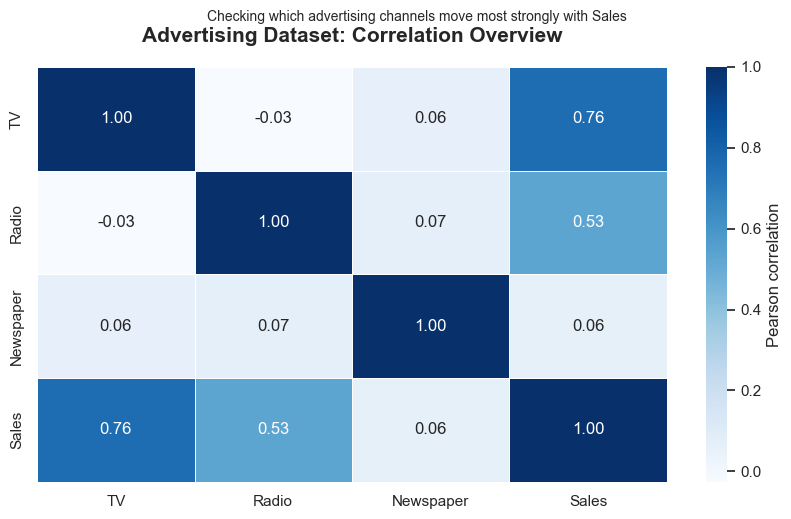

In [7]:
# ============================================================
# CELL 7 — CORRELATION HEATMAP
# ============================================================

# Create a clean figure size for print readability.
plt.figure(figsize=(8.5, 5.5))

# Draw the heatmap with readable labels and annotations.
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Pearson correlation"}
)

# Add a professional title and subtitle.
plt.title("Advertising Dataset: Correlation Overview", fontsize=15, fontweight="bold", pad=18)
plt.suptitle("Checking which advertising channels move most strongly with Sales", y=0.94, fontsize=10)

# Improve spacing for print output.
plt.tight_layout()
plt.show()

# Show conclusion after the chart.
show_conclusion(
    "Heatmap Reading",
    f"The heatmap confirms the strongest Sales relationship visually. <b>{strongest_corr_feature}</b> is the most important first signal, but regression will show model contribution more formally."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">12. MVD Task 1 — TV Budget vs Sales with Regression Line</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    
<p>This is the first required MVD plot: <b>TV budget vs Sales</b> with a regression line.</p>
<p><b>Why this plot matters:</b> before building the model, we want to see whether a straight-line relationship is reasonable. If the points roughly rise upward, a linear model is a sensible first baseline.</p>
<p><b>Required method:</b> the MVD explicitly asks for <code>sns.regplot</code>, so we use it here.</p>

  </div>
</div>

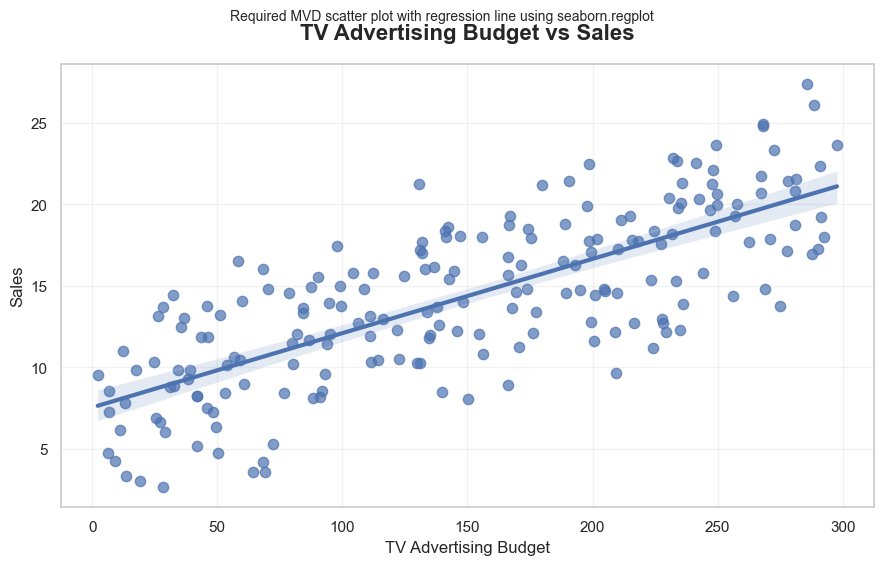

In [8]:
# ============================================================
# CELL 8 — REQUIRED SNS.REGPLOT: TV VS SALES
# ============================================================

# Create a print-ready figure.
plt.figure(figsize=(9, 6))

# sns.regplot creates the scatter plot and the best-fit regression line.
sns.regplot(
    data=advertising_df,
    x="TV",
    y="Sales",
    scatter_kws={"alpha": 0.70, "s": 55},
    line_kws={"linewidth": 3},
    ci=95
)

# Add title and explanatory subtitle.
plt.title("TV Advertising Budget vs Sales", fontsize=16, fontweight="bold", pad=18)
plt.suptitle("Required MVD scatter plot with regression line using seaborn.regplot", y=0.94, fontsize=10)

# Use business-friendly axis labels.
plt.xlabel("TV Advertising Budget")
plt.ylabel("Sales")

# Add a horizontal/vertical grid style that stays readable when printed.
plt.grid(axis="both", alpha=0.25)
plt.tight_layout()
plt.show()

# Conclude the required visual task.
show_conclusion(
    "MVD Task 1 Completed",
    "The scatter plot and regression line show the visual relationship between TV budget and Sales. If the points follow an upward pattern, TV is likely useful for predicting Sales."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">13. Train/Test Split for Simple TV Model</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    
<p>Now we prepare the first model: <b>TV only → Sales</b>.</p>
<p><b>Train/test split in simple words:</b> we teach the model on one part of the data and test it on unseen rows. This helps us check whether the model learned a useful pattern, not just memorized the training data.</p>
<p><b>Variable flow:</b> <code>advertising_df</code> → <code>X_tv</code> and <code>y</code> → <code>X_tv_train</code>, <code>X_tv_test</code>, <code>y_train</code>, <code>y_test</code>.</p>

  </div>
</div>

In [9]:
# ============================================================
# CELL 9 — TRAIN / TEST SPLIT FOR SIMPLE TV MODEL
# ============================================================

# X_tv contains the single input feature required for simple regression.
X_tv = advertising_df[["TV"]]

# y contains the target variable we want to predict.
y = advertising_df["Sales"]

# Split the data into training and test sets.
# random_state makes the split reproducible.
X_tv_train, X_tv_test, y_train, y_test = train_test_split(
    X_tv,
    y,
    test_size=0.20,
    random_state=42
)

# Print shapes so the user can see the variable flow clearly.
print("X_tv_train shape:", X_tv_train.shape)
print("X_tv_test shape: ", X_tv_test.shape)
print("y_train shape:   ", y_train.shape)
print("y_test shape:    ", y_test.shape)

# Show output-aware conclusion.
show_conclusion(
    "Train/Test Split Completed",
    f"The model will learn from <b>{X_tv_train.shape[0]}</b> training rows and will be evaluated on <b>{X_tv_test.shape[0]}</b> unseen test rows."
)

X_tv_train shape: (160, 1)
X_tv_test shape:  (40, 1)
y_train shape:    (160,)
y_test shape:     (40,)


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">14. Train Simple Linear Regression: TV Only</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    
<p>This cell fits the required simple linear regression model.</p>
<p><b>Model question:</b> if we only know TV advertising budget, how well can we predict Sales?</p>
<p><b>Key outputs:</b> intercept, TV coefficient, and the learned equation.</p>

  </div>
</div>

In [10]:
# ============================================================
# CELL 10 — TRAIN SIMPLE LINEAR REGRESSION MODEL
# ============================================================

# Create the simple LinearRegression model object.
simple_tv_model = LinearRegression()

# Fit the model using TV budget as input and Sales as target.
simple_tv_model.fit(X_tv_train, y_train)

# Extract the intercept. This is the predicted Sales value when TV budget is zero.
simple_intercept = simple_tv_model.intercept_

# Extract the TV coefficient. This tells how Sales changes when TV budget increases by 1 unit.
simple_tv_coefficient = simple_tv_model.coef_[0]

# Print the required model parameters.
print(f"Intercept:   {simple_intercept:.4f}")
print(f"Coefficient: {simple_tv_coefficient:.4f}")
print(f"Equation: Predicted Sales = {simple_intercept:.4f} + {simple_tv_coefficient:.4f} × TV")

# Explain the parameter output.
show_conclusion(
    "Simple Model Parameters",
    f"The TV coefficient is <b>{simple_tv_coefficient:.4f}</b>. This means that, in this fitted model, each extra unit of TV budget changes predicted Sales by about <b>{simple_tv_coefficient:.4f}</b> units."
)

Intercept:   7.6583
Coefficient: 0.0442
Equation: Predicted Sales = 7.6583 + 0.0442 × TV


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">15. Evaluate Simple TV Model</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    
<p>The MVD asks for <b>MSE</b> and <b>R²</b>. We also add RMSE and MAE because they are easier to explain in business terms.</p>
<p><b>Variable flow:</b> trained model + <code>X_tv_test</code> → <code>simple_test_predictions</code> → metrics.</p>

  </div>
</div>

In [11]:
# ============================================================
# CELL 11 — SIMPLE MODEL PREDICTIONS AND METRICS
# ============================================================

# Predict Sales for the unseen test rows.
simple_test_predictions = simple_tv_model.predict(X_tv_test)

# Calculate the required MSE metric.
simple_mse = mean_squared_error(y_test, simple_test_predictions)

# Calculate RMSE for easier business interpretation.
simple_rmse = np.sqrt(simple_mse)

# Calculate MAE as average absolute prediction error.
simple_mae = mean_absolute_error(y_test, simple_test_predictions)

# Calculate the required R² metric.
simple_r2 = r2_score(y_test, simple_test_predictions)

# Store the simple model metrics in a table.
simple_metrics = pd.DataFrame({
    "Model": ["Simple Linear Regression: TV only"],
    "MSE": [simple_mse],
    "RMSE": [simple_rmse],
    "MAE": [simple_mae],
    "R²": [simple_r2]
}).round(4)

# Display the metric table.
display(simple_metrics)

# Explain the actual output.
show_conclusion(
    "Simple Model Evaluation",
    f"The TV-only model achieved R² = <b>{simple_r2:.4f}</b> and RMSE = <b>{simple_rmse:.4f}</b>. This is our baseline before adding Radio and Newspaper."
)

,Model,MSE,RMSE,MAE,R²
0,Simple Linear Regression: TV only,9.0386,3.0064,2.6091,0.6401


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">16. Actual vs Predicted Chart for Simple Model</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    
<p>This chart checks how close the TV-only predictions are to the real Sales values.</p>
<p><b>How to read it:</b> points closer to the diagonal line are better predictions. Points far away from the line are larger errors.</p>

  </div>
</div>

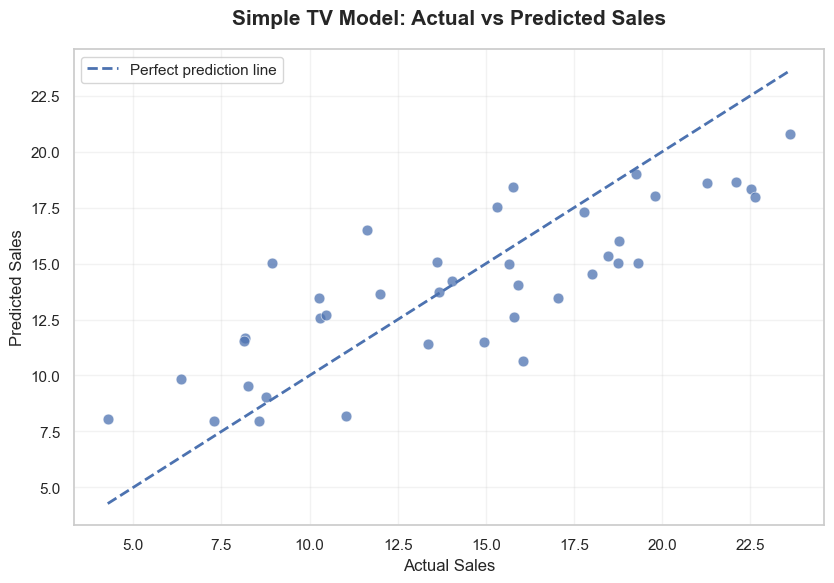

In [12]:
# ============================================================
# CELL 12 — ACTUAL VS PREDICTED CHART FOR SIMPLE MODEL
# ============================================================

# Create a dataframe for the simple model test results.
simple_prediction_df = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": simple_test_predictions
})

# Define chart boundaries using actual and predicted values.
min_value = min(simple_prediction_df["Actual Sales"].min(), simple_prediction_df["Predicted Sales"].min())
max_value = max(simple_prediction_df["Actual Sales"].max(), simple_prediction_df["Predicted Sales"].max())

# Create a print-ready scatter chart.
plt.figure(figsize=(8.5, 6))
plt.scatter(simple_prediction_df["Actual Sales"], simple_prediction_df["Predicted Sales"], alpha=0.75, s=60, edgecolor="white", linewidth=0.5)

# Add a diagonal perfect-prediction reference line.
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--", linewidth=2, label="Perfect prediction line")

# Add title and axis labels.
plt.title("Simple TV Model: Actual vs Predicted Sales", fontsize=15, fontweight="bold", pad=18)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.legend(frameon=True)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Explain chart output.
show_conclusion(
    "Simple Prediction Chart Reading",
    "The diagonal line represents perfect predictions. The distance of points from this line shows how much the TV-only model misses individual Sales values."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">17. Multiple Linear Regression: TV + Radio + Newspaper</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    
<p>Now we extend from one feature to three features.</p>
<p><b>Simple model question:</b> Can TV alone predict Sales?</p>
<p><b>Multiple model question:</b> Can TV, Radio, and Newspaper together predict Sales better?</p>
<p><b>Variable flow:</b> <code>advertising_df</code> → <code>X_all</code> and <code>y</code> → train/test split → multiple regression model.</p>

  </div>
</div>

In [13]:
# ============================================================
# CELL 13 — TRAIN / TEST SPLIT FOR MULTIPLE REGRESSION
# ============================================================

# X_all contains all three advertising features required by MVD Task 3.
feature_columns = ["TV", "Radio", "Newspaper"]
X_all = advertising_df[feature_columns]

# y is the same Sales target used by the simple model.
y = advertising_df["Sales"]

# Split all features into train and test sets using the same random_state.
X_all_train, X_all_test, y_train, y_test = train_test_split(
    X_all,
    y,
    test_size=0.20,
    random_state=42
)

# Print shapes to make the data flow clear.
print("X_all_train shape:", X_all_train.shape)
print("X_all_test shape: ", X_all_test.shape)
print("y_train shape:    ", y_train.shape)
print("y_test shape:     ", y_test.shape)

# Conclude the split step.
show_conclusion(
    "Multiple Regression Split Completed",
    f"The multiple model uses <b>{len(feature_columns)}</b> features: <b>{', '.join(feature_columns)}</b>. It will train on <b>{X_all_train.shape[0]}</b> rows and test on <b>{X_all_test.shape[0]}</b> rows."
)

X_all_train shape: (160, 3)
X_all_test shape:  (40, 3)
y_train shape:     (160,)
y_test shape:      (40,)


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">18. Train Multiple Linear Regression Model</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    
<p>This cell trains the multiple regression model using all three advertising channels.</p>
<p><b>Interpretation warning:</b> raw coefficients can be affected by feature scale. Later, we will also use standardized coefficients to compare feature contribution more fairly.</p>

  </div>
</div>

In [14]:
# ============================================================
# CELL 14 — TRAIN MULTIPLE LINEAR REGRESSION MODEL
# ============================================================

# Create the multiple LinearRegression model object.
multi_model = LinearRegression()

# Fit the model using all advertising features.
multi_model.fit(X_all_train, y_train)

# Store raw coefficients in a readable table.
raw_coefficient_table = pd.DataFrame({
    "Feature": feature_columns,
    "Raw Coefficient": multi_model.coef_
}).sort_values("Raw Coefficient", ascending=False)

# Display intercept and coefficients.
print(f"Intercept: {multi_model.intercept_:.4f}")
display(raw_coefficient_table.round(4))

# Identify the largest raw coefficient.
strongest_raw_feature = raw_coefficient_table.iloc[0]["Feature"]
strongest_raw_value = raw_coefficient_table.iloc[0]["Raw Coefficient"]

# Conclude based on actual output.
show_conclusion(
    "Multiple Model Trained",
    f"The largest raw coefficient belongs to <b>{strongest_raw_feature}</b> with value <b>{strongest_raw_value:.4f}</b>. We will later use standardized coefficients for a fairer feature-impact comparison."
)

Intercept: 2.7229


,Feature,Raw Coefficient
1,Radio,0.1978
0,TV,0.0458
2,Newspaper,-0.0034


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">19. Evaluate Multiple Regression Model</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    
<p>We now calculate the same metrics for the multiple model.</p>
<p><b>Main comparison:</b> if multiple regression has higher R² / adjusted R² and lower RMSE than the TV-only model, then adding Radio and Newspaper improves prediction.</p>

  </div>
</div>

In [15]:
# ============================================================
# CELL 15 — MULTIPLE MODEL PREDICTIONS AND METRICS
# ============================================================

# Predict Sales for the unseen test rows using all three features.
multi_test_predictions = multi_model.predict(X_all_test)

# Calculate error and fit metrics.
multi_mse = mean_squared_error(y_test, multi_test_predictions)
multi_rmse = np.sqrt(multi_mse)
multi_mae = mean_absolute_error(y_test, multi_test_predictions)
multi_r2 = r2_score(y_test, multi_test_predictions)

# Define a function for adjusted R².
def adjusted_r2(r2, n_rows, n_features):
    """Calculate adjusted R² using R², number of rows, and number of features."""
    return 1 - (1 - r2) * (n_rows - 1) / (n_rows - n_features - 1)

# Calculate adjusted R² for simple and multiple models.
simple_adjusted_r2 = adjusted_r2(simple_r2, len(y_test), 1)
multi_adjusted_r2 = adjusted_r2(multi_r2, len(y_test), len(feature_columns))

# Store metrics in a comparison-friendly table.
multi_metrics = pd.DataFrame({
    "Model": ["Multiple Linear Regression: TV + Radio + Newspaper"],
    "MSE": [multi_mse],
    "RMSE": [multi_rmse],
    "MAE": [multi_mae],
    "R²": [multi_r2],
    "Adjusted R²": [multi_adjusted_r2]
}).round(4)

# Display the table.
display(multi_metrics)

# Explain the output.
show_conclusion(
    "Multiple Model Evaluation",
    f"The multiple model achieved R² = <b>{multi_r2:.4f}</b>, adjusted R² = <b>{multi_adjusted_r2:.4f}</b>, and RMSE = <b>{multi_rmse:.4f}</b>. These values will now be compared against the TV-only baseline."
)

,Model,MSE,RMSE,MAE,R²,Adjusted R²
0,Multiple Linear Regression: TV + Radio + Newsp...,2.8378,1.6846,1.3853,0.887,0.8776


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">20. Compare Simple vs Multiple Regression</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    
<p>This cell directly answers the MVD question: <b>does multiple regression improve R²?</b></p>
<p><b>Adjusted R² note:</b> because multiple regression uses more features, adjusted R² is included to avoid blindly rewarding the model only for adding variables.</p>

  </div>
</div>

In [16]:
# ============================================================
# CELL 16 — SIMPLE VS MULTIPLE REGRESSION COMPARISON
# ============================================================

# Build a side-by-side model comparison table.
model_comparison = pd.DataFrame({
    "Model": [
        "Simple Linear Regression: TV only",
        "Multiple Linear Regression: TV + Radio + Newspaper"
    ],
    "Feature Count": [1, len(feature_columns)],
    "MSE": [simple_mse, multi_mse],
    "RMSE": [simple_rmse, multi_rmse],
    "MAE": [simple_mae, multi_mae],
    "R²": [simple_r2, multi_r2],
    "Adjusted R²": [simple_adjusted_r2, multi_adjusted_r2]
}).round(4)

# Display the comparison table.
display(model_comparison)

# Calculate improvement values.
r2_change = multi_r2 - simple_r2
rmse_change = simple_rmse - multi_rmse

# Create a conclusion sentence based on actual values.
if r2_change > 0:
    comparison_message = f"The multiple model improved R² by <b>{r2_change:.4f}</b> and reduced RMSE by <b>{rmse_change:.4f}</b>."
else:
    comparison_message = f"The multiple model did not improve R². R² changed by <b>{r2_change:.4f}</b>."

# Show output-aware conclusion.
show_conclusion(
    "Simple vs Multiple Regression Result",
    comparison_message + " This directly answers the MVD comparison requirement."
)

,Model,Feature Count,MSE,RMSE,MAE,R²,Adjusted R²
0,Simple Linear Regression: TV only,1,9.0386,3.0064,2.6091,0.6401,0.6306
1,Multiple Linear Regression: TV + Radio + Newsp...,3,2.8378,1.6846,1.3853,0.8870,0.8776


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">21. BI-Ready Model Comparison Chart</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    
<p>This chart turns the comparison table into a print-ready visual.</p>
<p><b>How to read it:</b> higher R² and adjusted R² mean stronger explained variation. A large gap between simple and multiple models means additional channels add predictive value.</p>

  </div>
</div>

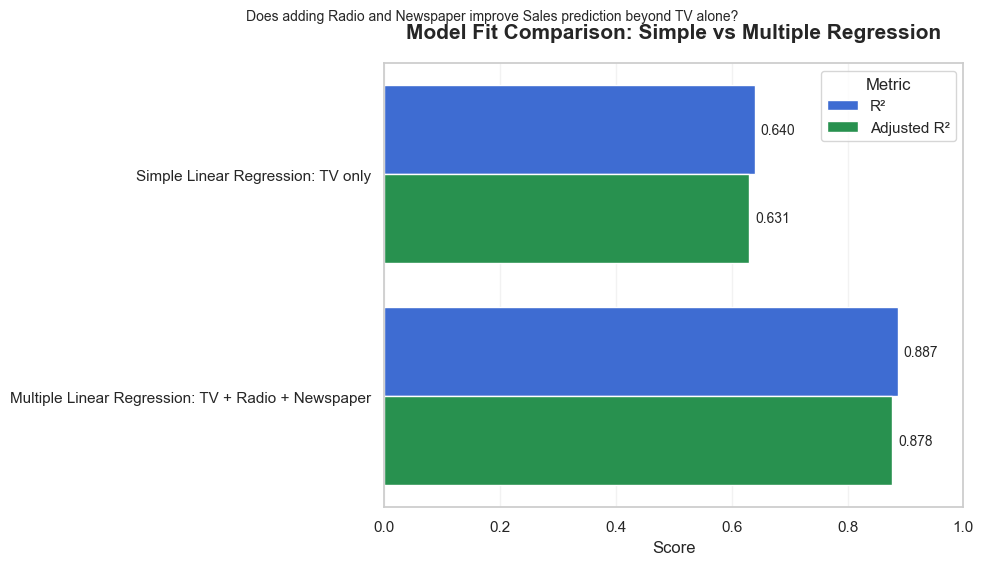

In [17]:
# ============================================================
# CELL 17 — BI-READY R² COMPARISON CHART
# ============================================================

# Reshape comparison table for plotting R² and adjusted R² together.
r2_plot_df = model_comparison.melt(
    id_vars="Model",
    value_vars=["R²", "Adjusted R²"],
    var_name="Metric",
    value_name="Score"
)

# Create a readable chart size.
plt.figure(figsize=(10, 6))

# Draw grouped bars for R² and adjusted R².
ax = sns.barplot(
    data=r2_plot_df,
    x="Score",
    y="Model",
    hue="Metric",
    palette=["#2563eb", "#16a34a"]
)

# Add value labels at the end of each bar.
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=4, fontsize=10)

# Add chart title and business subtitle.
plt.title("Model Fit Comparison: Simple vs Multiple Regression", fontsize=15, fontweight="bold", pad=18)
plt.suptitle("Does adding Radio and Newspaper improve Sales prediction beyond TV alone?", y=0.94, fontsize=10)
plt.xlabel("Score")
plt.ylabel("")
plt.xlim(0, 1)
plt.legend(title="Metric", frameon=True)
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

# Explain the visual output.
show_conclusion(
    "Chart Interpretation",
    f"The chart visually confirms the R² comparison. The R² change from simple to multiple regression is <b>{r2_change:.4f}</b>."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">22. Standardized Coefficients for Feature Contribution</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    
<p>The MVD asks: <b>Which feature contributes most?</b></p>
<p>Raw coefficients can be difficult to compare because features may have different scales. Standardized coefficients solve this by scaling the input features first.</p>
<p><b>Simple idea:</b> after scaling, a larger absolute coefficient means stronger model influence.</p>

  </div>
</div>

In [18]:
# ============================================================
# CELL 18 — STANDARDIZED COEFFICIENTS
# ============================================================

# Create a scaler that standardizes features to mean 0 and standard deviation 1.
scaler = StandardScaler()

# Fit the scaler only on training features to avoid data leakage.
X_all_train_scaled = scaler.fit_transform(X_all_train)

# Transform the test features using the training-fitted scaler.
X_all_test_scaled = scaler.transform(X_all_test)

# Train a linear model on the standardized features.
standardized_model = LinearRegression()
standardized_model.fit(X_all_train_scaled, y_train)

# Store standardized coefficients in a ranked table.
standardized_coefficient_table = pd.DataFrame({
    "Feature": feature_columns,
    "Standardized Coefficient": standardized_model.coef_,
    "Absolute Impact": np.abs(standardized_model.coef_)
}).sort_values("Absolute Impact", ascending=False)

# Display the ranked impact table.
display(standardized_coefficient_table.round(4))

# Identify the strongest feature using absolute standardized impact.
strongest_standardized_feature = standardized_coefficient_table.iloc[0]["Feature"]
strongest_standardized_value = standardized_coefficient_table.iloc[0]["Standardized Coefficient"]

# Explain the answer to the MVD question.
show_conclusion(
    "Feature Contribution Answer",
    f"Using standardized coefficients, the strongest contributor is <b>{strongest_standardized_feature}</b> with standardized coefficient <b>{strongest_standardized_value:.4f}</b>. This is the fairest answer to the MVD feature-contribution question."
)

,Feature,Standardized Coefficient,Absolute Impact
0,TV,3.9377,3.9377
1,Radio,2.8824,2.8824
2,Newspaper,-0.1159,0.1159


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">23. BI-Ready Feature Contribution Chart</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    
<p>This chart shows which advertising channel has the strongest model impact.</p>
<p><b>How to read it:</b> features are sorted by absolute standardized impact. Longer bars mean stronger influence on predicted Sales.</p>

  </div>
</div>

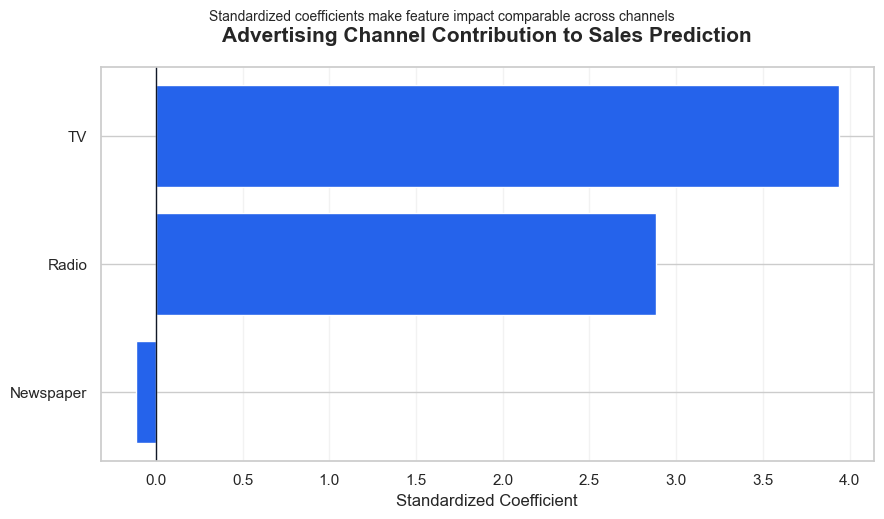

In [19]:
# ============================================================
# CELL 19 — FEATURE CONTRIBUTION CHART
# ============================================================

# Sort features from strongest to weakest impact for the chart.
feature_plot_df = standardized_coefficient_table.sort_values("Absolute Impact", ascending=True)

# Create the horizontal bar chart.
plt.figure(figsize=(9, 5.5))
plt.barh(feature_plot_df["Feature"], feature_plot_df["Standardized Coefficient"], color="#2563eb")

# Add a zero reference line.
plt.axvline(0, color="#111827", linewidth=1)

# Add title and subtitle.
plt.title("Advertising Channel Contribution to Sales Prediction", fontsize=15, fontweight="bold", pad=18)
plt.suptitle("Standardized coefficients make feature impact comparable across channels", y=0.94, fontsize=10)
plt.xlabel("Standardized Coefficient")
plt.ylabel("")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

# Explain chart output.
show_conclusion(
    "Feature Chart Interpretation",
    f"The chart confirms that <b>{strongest_standardized_feature}</b> has the largest standardized impact. This channel is the strongest driver in this fitted model."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">24. Residual Diagnostics — Prepare Residual Table</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    
<p>A model can have good metrics but still show problematic error patterns. Residual diagnostics help us check whether the model behaves sensibly.</p>
<p><b>Residual = Actual Sales − Predicted Sales.</b></p>
<p>Here we create a residual table for the multiple regression model because that is the richer final model in this notebook.</p>

  </div>
</div>

In [20]:
# ============================================================
# CELL 20 — RESIDUAL TABLE FOR MULTIPLE REGRESSION
# ============================================================

# Create a dataframe with actual values and predictions.
residual_df = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": multi_test_predictions
})

# Calculate residuals for each test row.
residual_df["Residual"] = residual_df["Actual Sales"] - residual_df["Predicted Sales"]

# Calculate absolute residuals for easier error sorting.
residual_df["Absolute Residual"] = residual_df["Residual"].abs()

# Display a compact residual sample.
display(residual_df.head().round(4))

# Summarize residual size.
mean_residual = residual_df["Residual"].mean()
mean_absolute_residual = residual_df["Absolute Residual"].mean()

# Explain the residual output.
show_conclusion(
    "Residual Table Created",
    f"The average residual is <b>{mean_residual:.4f}</b>, and the average absolute residual is <b>{mean_absolute_residual:.4f}</b>. Residuals close to zero mean predictions are close to actual Sales."
)

,Actual Sales,Predicted Sales,Residual,Absolute Residual
0,18.7711,20.0885,-1.3174,1.3174
1,16.0549,13.0576,2.9974,2.9974
2,15.3276,13.9713,1.3563,1.3563
3,17.7705,17.3410,0.4295,0.4295
4,8.7689,10.1004,-1.3315,1.3315


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">25. Residual Plot</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    
<p>The residual plot checks whether prediction errors show a pattern.</p>
<ul>
  <li><b>Good sign:</b> residuals are randomly scattered around zero.</li>
  <li><b>Warning sign:</b> curved pattern, funnel shape, or systematic trend.</li>
</ul>
<p>This helps check linearity and constant error spread.</p>

  </div>
</div>

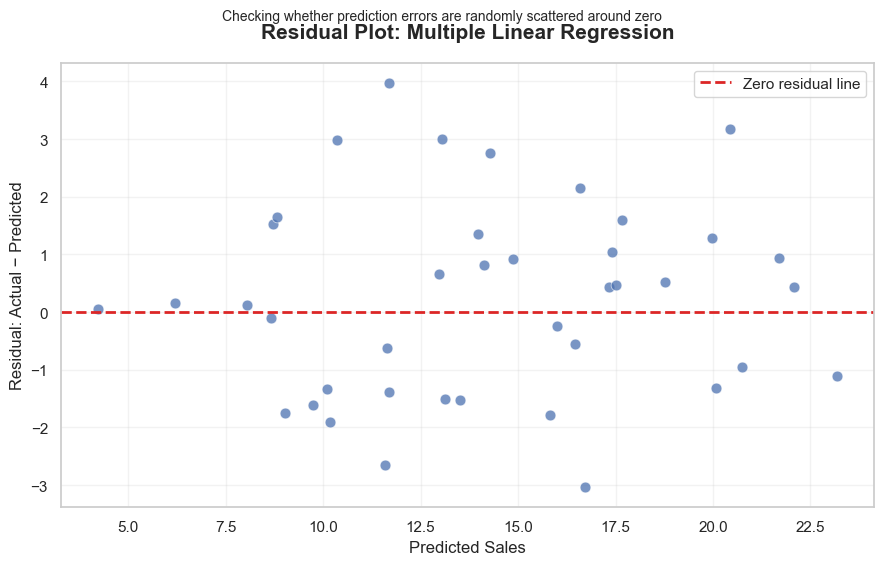

In [21]:
# ============================================================
# CELL 21 — RESIDUAL PLOT
# ============================================================

# Create a print-ready residual plot.
plt.figure(figsize=(9, 6))
plt.scatter(residual_df["Predicted Sales"], residual_df["Residual"], alpha=0.75, s=60, edgecolor="white", linewidth=0.5)

# Add zero-error reference line.
plt.axhline(0, color="#dc2626", linestyle="--", linewidth=2, label="Zero residual line")

# Add professional title and labels.
plt.title("Residual Plot: Multiple Linear Regression", fontsize=15, fontweight="bold", pad=18)
plt.suptitle("Checking whether prediction errors are randomly scattered around zero", y=0.94, fontsize=10)
plt.xlabel("Predicted Sales")
plt.ylabel("Residual: Actual − Predicted")
plt.legend(frameon=True)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Explain the purpose of this output.
show_conclusion(
    "Residual Plot Interpretation",
    "Use this chart to check whether residuals look randomly scattered. A clear curve or funnel shape would suggest that the simple linear model may be missing structure in the data."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">26. QQ Plot for Residual Normality</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    
<p>The QQ plot checks whether residuals are approximately normally distributed.</p>
<p><b>Simple explanation:</b> if the points follow the diagonal line, residuals are close to normal. If the tails bend far away, the residual distribution may be skewed or heavy-tailed.</p>
<p><b>Why it matters:</b> normality is especially important for statistical inference such as p-values and confidence intervals.</p>

  </div>
</div>

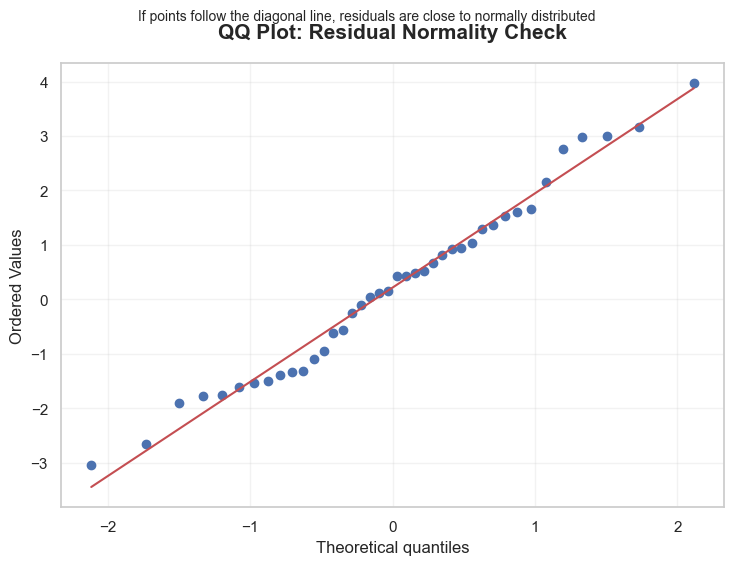

In [22]:
# ============================================================
# CELL 22 — QQ PLOT FOR RESIDUAL NORMALITY
# ============================================================

# Create a print-ready QQ plot.
plt.figure(figsize=(7.5, 6))
stats.probplot(residual_df["Residual"], dist="norm", plot=plt)

# Improve title and labels.
plt.title("QQ Plot: Residual Normality Check", fontsize=15, fontweight="bold", pad=18)
plt.suptitle("If points follow the diagonal line, residuals are close to normally distributed", y=0.94, fontsize=10)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Calculate skewness to support the visual interpretation.
residual_skewness = residual_df["Residual"].skew()

# Explain the QQ plot output.
show_conclusion(
    "QQ Plot Interpretation",
    f"The residual skewness is <b>{residual_skewness:.4f}</b>. Use this value together with the QQ plot: values closer to zero usually mean a more symmetric residual distribution."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">27. Statsmodels OLS Summary</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    
<p><b>scikit-learn</b> is prediction-focused. <b>statsmodels</b> gives statistical interpretation.</p>
<p>This section adds p-values, confidence intervals, F-statistic, and model-summary information. These are useful when a business stakeholder asks: <i>which variables are statistically meaningful?</i></p>

  </div>
</div>

In [23]:
# ============================================================
# CELL 23 — STATSMODELS OLS SUMMARY
# ============================================================

# Add a constant column so statsmodels can estimate the intercept.
X_all_train_sm = sm.add_constant(X_all_train)

# Fit an OLS model using the training data.
ols_model = sm.OLS(y_train, X_all_train_sm).fit()

# Print the full OLS summary.
print(ols_model.summary())

# Create a compact coefficient table for easier notebook reading.
ols_coefficient_table = pd.DataFrame({
    "Coefficient": ols_model.params,
    "P-value": ols_model.pvalues,
    "CI Lower": ols_model.conf_int()[0],
    "CI Upper": ols_model.conf_int()[1]
}).round(4)

# Display compact coefficient table.
display(HTML("<h4 style='font-family:Arial;'>Compact OLS Coefficient Table</h4>"))
display(ols_coefficient_table)

# Count statistically significant predictors at 5% level, excluding intercept.
significant_predictors = [idx for idx, value in ols_model.pvalues.items() if idx != "const" and value < 0.05]

# Explain output.
show_conclusion(
    "Statsmodels OLS Interpretation",
    f"At the 5% level, statistically significant predictors are: <b>{', '.join(significant_predictors) if significant_predictors else 'None'}</b>. Remember: p-values support inference, while test metrics support prediction quality."
)

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.875
Model:                            OLS   Adj. R-squared:                  0.872
Method:                 Least Squares   F-statistic:                     363.0
Date:                Sun, 14 Jun 2026   Prob (F-statistic):           4.13e-70
Time:                        21:05:49   Log-Likelihood:                -321.22
No. Observations:                 160   AIC:                             650.4
Df Residuals:                     156   BIC:                             662.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.7229      0.438      6.214      0.0

,Coefficient,P-value,CI Lower,CI Upper
const,2.7229,0.000,1.8574,3.5884
TV,0.0458,0.000,0.0424,0.0491
Radio,0.1978,0.000,0.1781,0.2176
Newspaper,-0.0034,0.427,-0.0119,0.0050


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">28. Multicollinearity Check with VIF</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    
<p><b>Multicollinearity</b> means input features overlap strongly with each other.</p>
<p><b>Why this matters:</b> when features overlap too much, coefficients can become unstable and harder to interpret.</p>
<p><b>VIF rule of thumb:</b> values around 1 are low concern. Values above 5 or 10 may need investigation.</p>

  </div>
</div>

In [24]:
# ============================================================
# CELL 24 — VIF MULTICOLLINEARITY CHECK
# ============================================================

# Add a constant column because VIF is calculated on a design matrix.
X_vif = sm.add_constant(X_all_train)

# Calculate VIF for each column in the design matrix.
vif_table = pd.DataFrame({
    "Feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})

# Remove the constant row from business interpretation.
vif_feature_table = vif_table[vif_table["Feature"] != "const"].copy()

# Display VIF values.
display(vif_feature_table.round(4))

# Identify the highest VIF among real features.
highest_vif_feature = vif_feature_table.sort_values("VIF", ascending=False).iloc[0]

# Explain the VIF output.
show_conclusion(
    "VIF Interpretation",
    f"The highest feature VIF is for <b>{highest_vif_feature['Feature']}</b> with VIF = <b>{highest_vif_feature['VIF']:.4f}</b>. Low VIF values mean the advertising features are not heavily overlapping in this model."
)

,Feature,VIF
1,TV,1.0033
2,Radio,1.0189
3,Newspaper,1.0174


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">29. Final Notebook Summary and MVD Proof</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    
<p>This final cell collects the key model results and confirms MVD completion.</p>
<p><b>Print-ready purpose:</b> after running the notebook, this section gives a compact final result table and a business takeaway.</p>

  </div>
</div>

In [25]:
# ============================================================
# CELL 25 — FINAL SUMMARY AND MVD COMPLETION CHECKLIST
# ============================================================

# Create a final comparison table with the most important metrics.
final_result_table = model_comparison[["Model", "Feature Count", "RMSE", "MAE", "R²", "Adjusted R²"]].copy()

# Create the MVD completion checklist.
mvd_checklist = pd.DataFrame({
    "MVD Requirement": [
        "Load Advertising dataset",
        "Create TV vs Sales scatter plot with regression line using sns.regplot",
        "Train simple regression using TV only",
        "Print coefficient and intercept",
        "Print MSE and R²",
        "Train multiple regression using TV, Radio, Newspaper",
        "Compare R² between simple and multiple regression",
        "Identify strongest contributing feature"
    ],
    "Completed In Notebook": [
        "Yes — data loading and validation cells",
        "Yes — required regplot chart",
        "Yes — simple TV model cells",
        "Yes — simple model parameter cell",
        "Yes — simple model metric cell",
        "Yes — multiple regression cells",
        "Yes — comparison table and chart",
        f"Yes — strongest feature: {strongest_standardized_feature}"
    ]
})

# Display final result and checklist tables.
display(HTML("<h4 style='font-family:Arial;'>Final Model Result Table</h4>"))
display(final_result_table.round(4))

display(HTML("<h4 style='font-family:Arial;'>MVD Completion Checklist</h4>"))
display(mvd_checklist)

# Create final business recommendation based on actual metrics.
if multi_r2 >= simple_r2:
    recommendation = f"Use the multiple regression model because it explains more Sales variation than TV alone. The strongest standardized feature is {strongest_standardized_feature}."
else:
    recommendation = f"The TV-only model is competitive in this run. Review whether Radio and Newspaper add enough business value before using the larger model."

# Show final print-ready conclusion.
show_conclusion(
    "Final Business Takeaway",
    f"{recommendation} Final multiple-model R² is <b>{multi_r2:.4f}</b> and adjusted R² is <b>{multi_adjusted_r2:.4f}</b>. This notebook completes the Beginner Linear Regression MVD requirements."
)

,Model,Feature Count,RMSE,MAE,R²,Adjusted R²
0,Simple Linear Regression: TV only,1,3.0064,2.6091,0.6401,0.6306
1,Multiple Linear Regression: TV + Radio + Newsp...,3,1.6846,1.3853,0.8870,0.8776


,MVD Requirement,Completed In Notebook
0,Load Advertising dataset,Yes — data loading and validation cells
1,Create TV vs Sales scatter plot with regressio...,Yes — required regplot chart
2,Train simple regression using TV only,Yes — simple TV model cells
3,Print coefficient and intercept,Yes — simple model parameter cell
4,Print MSE and R²,Yes — simple model metric cell
5,"Train multiple regression using TV, Radio, New...",Yes — multiple regression cells
6,Compare R² between simple and multiple regression,Yes — comparison table and chart
7,Identify strongest contributing feature,Yes — strongest feature: TV


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">30. Final Learning Recap</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    
<p>This notebook covered the first Day 12 block in a complete, print-ready way.</p>
<table style="border-collapse:collapse; width:100%; font-size:14px;">
  <tr style="background:#dbeafe;"><th style="border:1px solid #bfdbfe; padding:8px; text-align:left;">Concept</th><th style="border:1px solid #bfdbfe; padding:8px; text-align:left;">What You Should Remember</th></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>Linear Regression</b></td><td style="border:1px solid #e5e7eb; padding:8px;">Predicts a numeric target using a straight-line relationship.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>OLS / Least Squares</b></td><td style="border:1px solid #e5e7eb; padding:8px;">Finds coefficients by minimizing squared residuals.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>Simple Regression</b></td><td style="border:1px solid #e5e7eb; padding:8px;">Uses one input feature, here TV budget.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>Multiple Regression</b></td><td style="border:1px solid #e5e7eb; padding:8px;">Uses several input features together.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>Residual Diagnostics</b></td><td style="border:1px solid #e5e7eb; padding:8px;">Checks whether errors behave reasonably.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>Business Interpretation</b></td><td style="border:1px solid #e5e7eb; padding:8px;">Translates model metrics and coefficients into campaign-planning insight.</td></tr>
</table>

  </div>
</div>